SALES PERFORMANCE ANALYSIS
1. BUSSINES UNDERSTANDING
   Perusahaan ingin mengetahui performa dari setiap tahun nya apakah perusahaan mengalami perkembangan atau tidak dengan mengambil data penjualan toko dari tahun 2015 - 2018, 
   analisis ini bertujuan untuk memberikan hasil yang dapat digunakan untuk pengambilan keputusan bisnis, seperti pembukaan cabang baru, penambahan stok di gudang, hingga
   penambahan tenaga kerja baru.

2. DATA UNDERSTANDING

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Memanggil library yang diperlukan

In [3]:
df = pd.read_csv(r"D:\PROJECT\Superstore Sales Dataset\Superstore Sales Dataset.csv")
df.head()

# Memanggil data set dan melihat isi data set, bagian paling atas

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
print(df.columns)

# Melihat list kolom yang ada di data set berjumlah berapa

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [5]:
df.info()

# Melihat tipe data setiap kolom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

3. DATA CLEANING & PREPARATION

In [6]:
df.isnull().sum()

# Pemeriksaan Kolom dataset yang memiliki nilai nol

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [7]:
df = df.drop(columns=["Postal Code"])

# Terdapat nilai nol di colom "Postal Code" sehingga karena tidak mempengaruhi dalam analisis ini, maka kolom tersebut dihilangkan

In [8]:
df.duplicated().sum()

# Memeriksa apakah ada data yang sama atau kembar di data set

0

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format="%d/%m/%Y")
df.info()

# Karena pada analisis ini membutuhkan kolom Order Date sehingga kita ubah tipe data nya yang semula string diubah menjadi format datetime
# Data set memiliki format yang berbeda dengan biasanya, maka disesuaikan dengan format yg ada di dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   object        
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Region         9800 non-null   object        
 12  Product ID     9800 non-null   object        
 13  Category       9800 non-null   object        
 14  Sub-Category   9800 non-null   object        
 15  Product Name   9800 n

4. FEATURE ENGINEERING

In [23]:
df["Tahun"] = df['Order Date'].dt.year
df["Bulan"] = df['Order Date'].dt.month
df["Hari"] = df['Order Date'].dt.day
df["nama_bulan"] = df['Order Date'].dt.month_name()
df["nama_hari"] = df['Order Date'].dt.day_name()

# Mebuat fitur baru pada bagian kolom Order Date di pecah menjadi Tahun, Bulan, dan Hari lalu memberikan nama bulan dan hari sesuai dengan tanggal dan bulan

5. KPI ANALYSIS

In [24]:
total_penjualan = df["Sales"].sum()
total_transaksi = df['Order ID'].nunique()
total_pelanggan = df['Customer ID'].nunique()
rata_transaksi = total_penjualan/total_transaksi
rata_customer = total_penjualan/total_pelanggan


print(f"Total Sales                     : ${total_penjualan:,.2f}")
print(f"Total Transaksi                 : {total_transaksi}")
print(f'Total Pelanggan                 : {total_pelanggan}')
print(f'Rata Rata Transaksi             : ${rata_transaksi:,.2f}')
print(f'Rata Rata Pengeluaran Pelanggan : ${rata_customer:,.2f}')

# Melakukan perhitungan total pada data set


Total Sales                     : $2,261,536.78
Total Transaksi                 : 4922
Total Pelanggan                 : 793
Rata Rata Transaksi             : $459.48
Rata Rata Pengeluaran Pelanggan : $2,851.87


6. TREND ANALYSIS

In [25]:
salesperbulan = (
    df.groupby(["Bulan"])['Sales']
    .sum()
    .reset_index()
)
salesperbulan.head()

# Membuat grup baru yang hanya berisi Bulan dan total sales pada bulan tersebut

,Bulan,Sales
0,1,94291.6296
1,2,59371.1154
2,3,197573.5872
3,4,136283.0006
4,5,154086.7237


In [26]:
salespertahun = (
    df.groupby(["Tahun"])['Sales']
    .sum()
    .reset_index()
)
salespertahun.head()

# Membuat grup baru untuk tahun untuk bisa menghitung apakah penjualan tiap tahun mengalami kenaikan atau tidak

,Tahun,Sales
0,2015,479856.2081
1,2016,459436.0054
2,2017,600192.5500
3,2018,722052.0192


In [27]:
month_order = [
'January',
'February',
'March',
'April',
'May',
'June',
'July',
'August',
'September',
'October',
'November',
'December'
]

df["nama_bulan"] = pd.Categorical(
    df["nama_bulan"],
    categories=month_order,
    ordered=True
)

# Mengidentifikasi nama nama bulan lagi dengan sesuai urutan pada tanggal agar pada saat menampilkan data terlihat rapih

In [28]:
salesnamabulan = (
    df.groupby("nama_bulan")["Sales"]
      .sum()
)
salesnamabulan.head()

# Membuat grup baru pada bulan yang diberikan nama agar bisa melihat bulan mana yang memiliki penjualan tertinggi

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_46640\4101885818.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("nama_bulan")["Sales"]


nama_bulan
January      94291.6296
February     59371.1154
March       197573.5872
April       136283.0006
May         154086.7237
Name: Sales, dtype: float64

In [29]:
day_order = [
'Monday',
'Tuesday',
'Wednesday',
'Thursday',
'Friday',
'Saturday',
'Sunday'
]

df["nama_hari"] = pd.Categorical(
    df["nama_hari"],
    categories=day_order,
    ordered=True
)
# Mengidentifikasi nama nama hari dengan sesuai urutan pada tanggal agar pada saat menampilkan data terlihat rapih

In [30]:
salesnamahari = (
    df.groupby(["nama_hari"])['Sales']
    .sum()
)
salesnamahari.head()

# Membuat grup baru untuk nama nama hari yang bertujuan agar bisa melihat hari apa penjualan tertinggi

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_46640\4106005351.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["nama_hari"])['Sales']


nama_hari
Monday       348791.5516
Tuesday      420535.9243
Wednesday    315888.9722
Thursday     142839.2402
Friday       234710.8402
Name: Sales, dtype: float64

6. SALES TREND ANALYSIS

In [31]:
print(f"Sales Tertinggi terdapat di bulan {salesnamabulan.idxmax()}, dengan nilai sebesar ${salesnamabulan.max():,.2f}")

# Memanggil lagsung grup untuk nama bulan untuk mengetahui bulan mana yang memiliki penjualan terbanyak serta nilai nya

Sales Tertinggi terdapat di bulan November, dengan nilai sebesar $350,161.71


In [32]:
print(f"Sales Tertinggi terdapat pada hari {salesnamahari.idxmax()}, dengan nilai sebesar ${salesnamahari.max():,.2f}")

# Memanggil langsung grup nama hari untuk memberikan nilai mana yang memiliki penjualan terbanyak serta nilai nya

Sales Tertinggi terdapat pada hari Saturday, dengan nilai sebesar $420,901.48


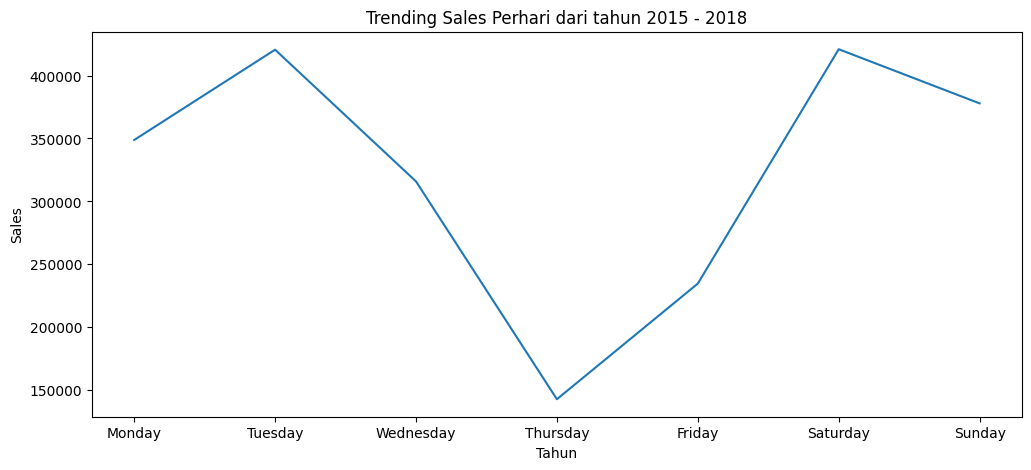

In [33]:
plt.figure(figsize=(12,5))

plt.plot(salesnamahari.index, salesnamahari.values)

plt.title("Trending Sales Perhari dari tahun 2015 - 2018")
plt.xlabel("Tahun")
plt.ylabel("Sales")

plt.show()

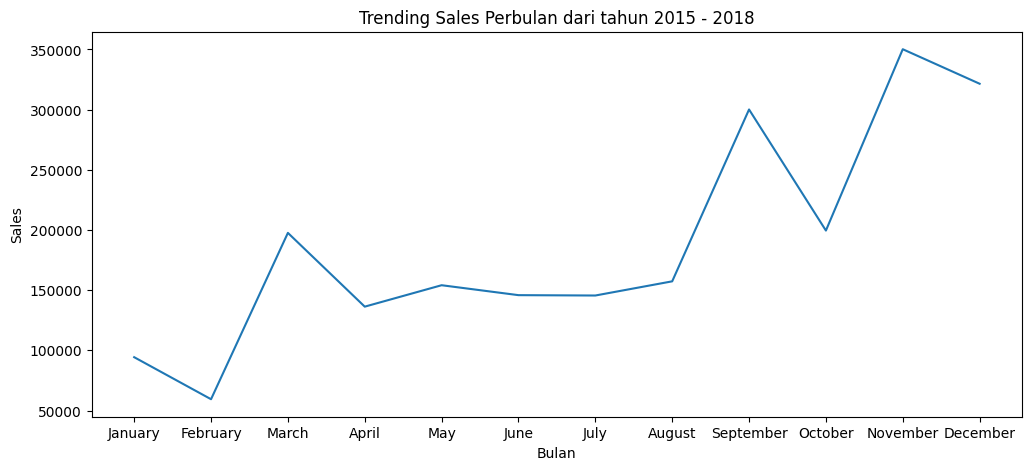

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(salesnamabulan.index, salesnamabulan.values)

plt.title("Trending Sales Perbulan dari tahun 2015 - 2018")
plt.xlabel("Bulan")
plt.ylabel("Sales")

plt.show()

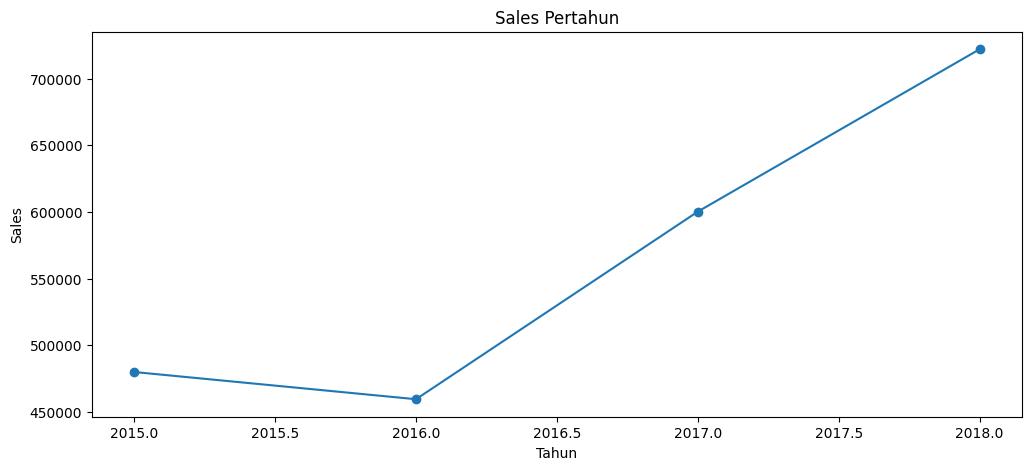

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(salespertahun["Tahun"], salespertahun["Sales"], marker='o')

plt.title("Sales Pertahun")
plt.xlabel("Tahun")
plt.ylabel("Sales")

plt.show()

7. CONCLUSION

Berdasarkan hasil analisis dari data set Sales Performance dapat disimpulkan bahwa:

- Total penjualan perusahaan hingga $2.26 juta.
- Dataset berisi 4.922 transaksi yang dilakukan oleh 793 pelanggan.
- Nilai rata-rata transaksi yang dibelanjakan pelanggan sebesar $459.48.
- Penjualan menunjukkan tren pertumbuhan setiap tahun walaupun pada tahun 2015 - 2016 mengalami penurunan, tetapi di tahun berikutnya penjualan naik drastis.
- November merupakan bulan dengan penjualan tertinggi.
- Sabtu merupakan hari dengan total penjualan terbesar.
- Kamis merupakan hari dengan total penjualan terkecil.

Secara keseluruhan perusahaan menunjukkan performa penjualan yang positif selama periode 2015 - 2018.

8. BUSINESS RECOMMENDATION

- Tingkatkan persediaan barang pada bulan september karena penjualan pada bulan tersebut cenderung lebih tinggi.
- Utamakan barang-barang selalu tersedia terutama di hari sabtu.
- Lakukan analisis lanjutan terhadap kategori produk dan pelanggan untuk mengetahui faktor utama yang mendorong peningkatan penjualan.
- Analisis lanjutan untuk pembukaan cabang baru untuk daerah daerah yg memiliki potensi penjualan nya tinggi